In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('/home/fverdian/class/soundspeed-scripts/kernels-fullnum/numerical-integrals')
from num_kernels import NumKernels, PLfromClass
from scipy.interpolate import interp1d
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
})

In [2]:
fx=0.1
t_ini = -5
fullt=np.linspace(t_ini,30, 300)
teval=0
kref=1.
supprshift=100
nk = NumKernels(fx=fx, kref=kref, fullt=fullt, rtol=0.0001)
def g_ank(k):
    return nk.g_an(-2*np.log(k/kref))
def h_ank(k):
    return nk.h_an(-2*np.log(k/kref))

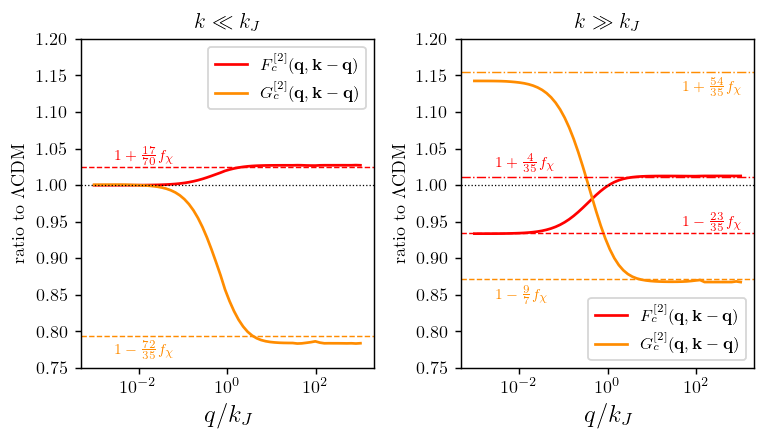

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3.5), dpi=130)

mup=0. #MUST EVALUATE IT AT mu=0, otherwise the eds has a divergence
kplow=1.e-3
qlist=np.logspace(-3,3,60)
Flist_low=[];Flist_high=[]
for qp in qlist:
    print(f'q={qp:.1e}', end='\r')
    kMq = np.sqrt(kplow**2 + qp**2 - 2*kplow*qp*mup)
    cT12 = (kplow*mup-qp)/kMq
    F2c,G2_c,F2x,_=nk.solve_F2([qp,kMq,cT12])
    Flist_low.append([F2c,nk.F2_0(kplow,qp,mup), G2_c, nk.G2_0(kplow,qp,mup)])
Flist_low=np.array(Flist_low);

# First plot
ax1.plot(qlist,Flist_low[:,0]/Flist_low[:,1], 'r', label=r'$F_c^{[2]}(\mathbf{q},\mathbf{k}-\mathbf{q})$')
ax1.plot(qlist,Flist_low[:,2]/Flist_low[:,3], 'darkorange', label=r'$G_c^{[2]}(\mathbf{q},\mathbf{k}-\mathbf{q})$')
DeltaF2c_qkMq_limB = (51*fx)/210
ax1.axhline(1+DeltaF2c_qkMq_limB, color='r', linestyle='--', linewidth=0.8)
ax1.axhline(1, color='k', linestyle=':', linewidth=0.7)
ax1.axhline(1-72/35*fx, color='darkorange', linestyle='--', linewidth=0.8)

ax1.text(3.e-3, 1.035, r'$1+\frac{17}{70}f_\chi$', color='r', fontsize=8)
ax1.text(3.e-3, 0.77, r'$1-\frac{72}{35}f_\chi$', color='darkorange', fontsize=8)
ax1.legend(fontsize=9, loc='upper right')
ax1.set_ylim([0.75,1.2])
ax1.set_title(r'$k\ll k_J$')
ax1.set_ylabel(r'ratio to $\Lambda$CDM', fontsize=10)
ax1.set_xscale('log')
ax1.set_xlabel(r'$q/k_J$', fontsize=14)

kphigh=10
qlist=np.logspace(-3,3,60)
Flist_high=[]
for qp in qlist:
    print(f'q={qp:.1e}', end='\r', flush=True)
    kMq = np.sqrt(kphigh**2 + qp**2 - 2*kphigh*qp*mup)
    cT12 = (kphigh*mup-qp)/kMq
    F2c,G2_c,F2x,_=nk.solve_F2([qp,kMq,cT12], return_timedep=False)
    Flist_high.append([F2c,nk.F2_0(kphigh,qp,mup), G2_c, nk.G2_0(kphigh,qp,mup)])
Flist_high=np.array(Flist_high)

# Second plot
ax2.plot(qlist,Flist_high[:,0]/Flist_high[:,1], 'r', label=r'$F_c^{[2]}(\mathbf{q},\mathbf{k}-\mathbf{q})$')
ax2.plot(qlist,Flist_high[:,2]/Flist_high[:,3], 'darkorange', label=r'$G_c^{[2]}(\mathbf{q},\mathbf{k}-\mathbf{q})$')

DeltaF2c_qkMq_limD = -23/35*fx
ax2.axhline(1+DeltaF2c_qkMq_limD, color='r', linestyle='--', linewidth=0.8)
ax2.text(5.e1, 0.945, r'$1-\frac{23}{35}f_\chi$', color='r', fontsize=8)

DeltaF2c_qkMq_limC = 4/35*fx
ax2.axhline(1+DeltaF2c_qkMq_limC, color='r', linestyle='-.', linewidth=0.8)
ax2.text(3.e-3, 1.025, r'$1+\frac{4}{35}f_\chi$', color='r', fontsize=8)

ax2.axhline(1+54/35*fx, color='darkorange', linestyle='-.', linewidth=0.8)
ax2.text(5.e1, 1.13, r'$1+\frac{54}{35}f_\chi$', color='darkorange', fontsize=8)

ax2.axhline(1-9/7*fx, color='darkorange', linestyle='--', linewidth=0.8)
ax2.text(3.e-3, 0.845, r'$1-\frac{9}{7}f_\chi$', color='darkorange', fontsize=8)

ax2.axhline(1, color='k', linestyle=':', linewidth=0.7)
ax2.legend(fontsize=9, loc='lower right')
ax2.set_title(r'$k\gg k_J$')
ax2.set_xscale('log')
ax2.set_ylabel(r'ratio to $\Lambda$CDM', fontsize=10)
ax2.set_xlabel(r'$q/k_J$', fontsize=14)
ax2.set_ylim([0.75,1.2])
plt.tight_layout()
# plt.savefig('/home/fverdian/class/soundspeed-scripts/plots4paper/figure/F2c_qkMq.pdf', bbox_inches='tight')
plt.show()

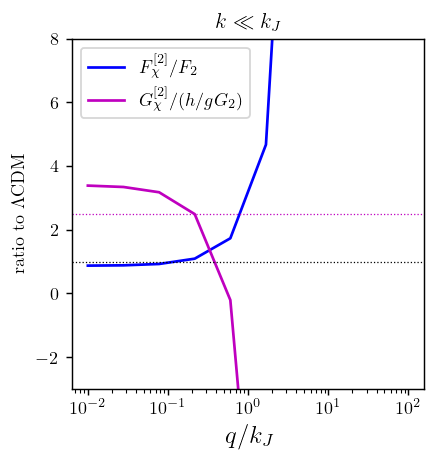

In [9]:
plt.figure(figsize=(3.5, 3.5), dpi=130)

mup=0. #MUST EVALUATE IT AT mu=0, otherwise the eds has a divergence
kplow=1.e-3
qlist=np.logspace(-3,np.log10(50),60)
Flist_low=[]
# for qp in qlist:
#     print(f'q={qp:.1e}', end='\r')
#     kMq = np.sqrt(kplow**2 + qp**2 - 2*kplow*qp*mup)
#     cT12 = (kplow*mup-qp)/kMq
#     F2c,_,F2x,G2x= nk.solve_F2([qp,kMq,cT12], return_timedep=False)
#     Flist_low.append([F2x,nk.F2_0(kplow,qp,mup), G2x, nk.G2_0(kplow,qp,mup)])
# Flist_low=np.array(Flist_low).T;

# First plot
# plt.plot(qlist,Flist_low[0]/Flist_low[1], 'b', label=r'$\tilde F_\chi^{[2]}(\mathbf{q},\mathbf{k}-\mathbf{q})$')
# plt.plot(qlist,Flist_low[2]/Flist_low[1], 'm', label=r'$\tilde G_\chi^{[2]}(\mathbf{q},\mathbf{k}-\mathbf{q})$')

# plt.plot(qlist,Flist_low[0]/Flist_low[1], 'b', label=r'$F_\chi^{[2]}/F_2$')
# plt.plot(qlist,Flist_low[2]/Flist_low[3], 'm', label=r'$G_\chi^{[2]}/G_2$')
# plt.plot(qlist,Flist_low[2]/Flist_low[1], 'm--', label=r'$G_\chi^{[2]}/F_2$')

F2chi_qkMq_limB = 3/10
# plt.axhline(F2chi_qkMq_limB, color='b', linestyle='--', linewidth=1)
# plt.text(3.e-3, 0.33, r'$\frac{3}{10}$', color='b', fontsize=9)
# plt.text(10, 0.7, r'$\frac{3}{5}$', color='m', fontsize=9)


plt.legend()
plt.ylim([-3.,8])
plt.title(r'$k\ll k_J$')
plt.ylabel(r'ratio to $\Lambda$CDM', fontsize=10)
plt.xscale('log')
plt.xlabel(r'$q/k_J$', fontsize=14)
# plt.savefig('/home/fverdian/class/soundspeed-scripts/plots4paper/figure/FGchi.pdf', bbox_inches='tight')
plt.show()

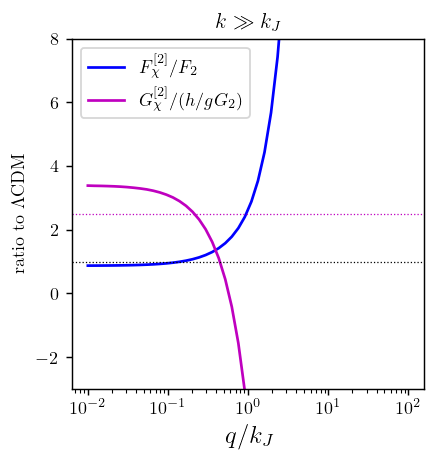

In [11]:
plt.figure(figsize=(3.5, 3.5), dpi=130)

mup=0. #MUST EVALUATE IT AT mu=0, otherwise the eds has a divergence
kphigh=30
qlist=np.logspace(-2,2,50)
Flist_high=[]
for qp in qlist:
    print(f'q={qp:.1e}', end='\r', flush=True)
    kMq = np.sqrt(kphigh**2 + qp**2 - 2*kphigh*qp*mup)
    cT12 = (kphigh*mup-qp)/kMq
    F2c,G2_c,F2x,G2x=nk.solve_F2([qp,kMq,cT12], return_timedep=False)
    Flist_high.append([F2x/g_ank(qp)/g_ank(kMq),nk.F2_0(kphigh,qp,mup), G2x/g_ank(qp)/g_ank(kMq), h_ank(kphigh)/g_ank(kphigh)*nk.G2_0(kphigh,qp,mup)])
Flist_high=np.array(Flist_high).T

plt.plot(qlist,Flist_high[0]/Flist_high[1], 'b', label=r'$F_\chi^{[2]}/F_2$')
plt.plot(qlist,Flist_high[2]/Flist_high[3], 'm', label=r'$G_\chi^{[2]}/(h/g G_2)$')

plt.axhline(1, color='k', linestyle=':', linewidth=0.7)
plt.axhline(2.5, color='m', linestyle=':', linewidth=0.7)

plt.legend()
plt.ylim([-3.,8])
plt.title(r'$k\gg k_J$')
plt.ylabel(r'ratio to $\Lambda$CDM', fontsize=10)
plt.xscale('log')
plt.xlabel(r'$q/k_J$', fontsize=14)
# plt.savefig('/home/fverdian/class/soundspeed-scripts/plots4paper/figure/FGchi.pdf', bbox_inches='tight')
plt.show()

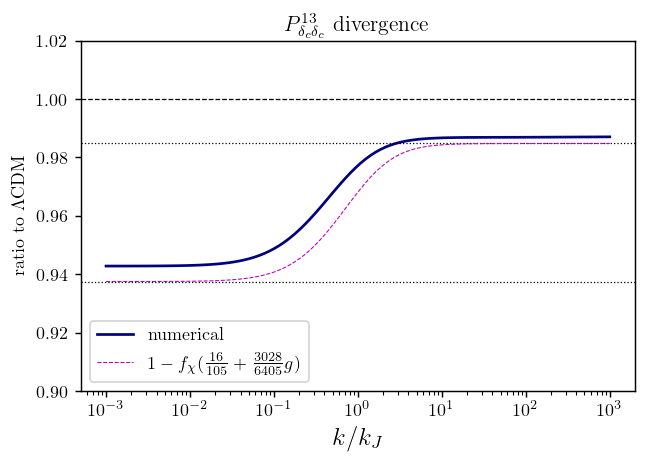

In [43]:
eta, val = np.loadtxt('/home/fverdian/class/soundspeed-scripts/plots4paper/UV-Pcc_F3Data.dat', unpack=True)

div_of_eta = interp1d(eta, val, fill_value='extrapolate')


plt.figure(figsize=(5.5, 3.5), dpi=130)

Edsdiv = -61/630/np.pi**2
lim1 = (Edsdiv + 0.1* 286/4725/np.pi**2)
lim2 = (Edsdiv + 0.1* 488/33075/np.pi**2)

kvals = np.logspace(-3,3,100)
plt.plot(kvals,div_of_eta(-2*np.log(kvals))/Edsdiv, 'navy', label=r'numerical')

plt.axhline(1, color='k', linestyle='--', linewidth=0.7)
plt.axhline(lim1/Edsdiv, color='k', linestyle=':', linewidth=0.7)
plt.axhline(lim2/Edsdiv, color='k', linestyle=':', linewidth=0.7)

plt.plot(kvals,1-0.1*(16/105 + 3028/6405*nk.g_an(-2*np.log(kvals))), 'm--', linewidth=0.6, label=r'$1-f_\chi(\frac{16}{105} + \frac{3028}{6405}g)$')


plt.legend()
plt.ylim([0.9,1.02])
plt.title(r'$P^{13}_{\delta_c\delta_c}$ divergence')
plt.ylabel(r'ratio to $\Lambda$CDM', fontsize=10)
plt.xscale('log')
plt.xlabel(r'$k/k_J$', fontsize=14)
# plt.savefig('/home/fverdian/class/soundspeed-scripts/plots4paper/figure/Pcc-UV-divergence.pdf', bbox_inches='tight')
plt.show()

In [18]:
-2*np.log(100)

-9.210340371976182